In [13]:
import sys
sys.path.append('..')

from matplotlib import pyplot as plt
from src.analysis import break_even_analysis, comparative_statics, stochastic_bivariate_simulation, run_monte_carlo, \
    run_two_way_sensitivity_analysis
from src.config import variable_names
from src.engine import evaluate_chained_models, evaluate_variable_scenario_sweep, evaluate_expected_scenario
from src.models import ProfitModel, CostOfGoodsSoldModel, RevenueModel, FreeCashFlowModel, \
    CapitalExpenditureModel, DepreciationModel, TotalExpenseModel, NetIncomeModel, RoiModel, TotalCostModel, \
    AdvertisingEfficiencyModel
from src.variables import Orders, SellingPrice, PurchasingPrice, ItemsPerOrder, USDToRMB, Rent, TaxRate, \
    CostPerAcquisition, ConversionRate, RenderFee, TravelFee, AdvertisingCost, Expense
from src.visualization import generate_linear_regression_from_lists

In [14]:
cogs_model = CostOfGoodsSoldModel()
cost_model = TotalCostModel()
revenue_model = RevenueModel()
expense_model = TotalExpenseModel()
depreciation_model = DepreciationModel()
capital_expenditure_model = CapitalExpenditureModel()
net_income_model = NetIncomeModel()
advertising_efficiency_model = AdvertisingEfficiencyModel()
free_cash_flow_model = FreeCashFlowModel()
profit_model = ProfitModel()
roi_model = RoiModel()

advertising_budget = AdvertisingCost(min_value=10000, max_value=30000)
orders = Orders(min_value=20, max_value=30)
usd_to_rmb = USDToRMB(expected_value=6.8, min_value=6.0, max_value=7.5)
selling_price = SellingPrice(min_value=3000, max_value=6000)
items_per_order = ItemsPerOrder(min_value=1, max_value=5)
purchasing_price = PurchasingPrice(min_value=1000, max_value=2000)
conversion_rate = ConversionRate(min_value=0.04, max_value=0.2)
cpa = CostPerAcquisition(min_value=12, max_value=36)
expense = Expense(0)

In [15]:
variables = {variable_names.DEAL_PURCHASING_PRICE: purchasing_price,
             variable_names.DEAL_ORDERS: orders,
             variable_names.FINANCE_USD_TO_RMB: usd_to_rmb,
             variable_names.COST_ADVERTISING: advertising_budget,
             variable_names.COST_CONVERSION_RATE: conversion_rate,
             variable_names.COST_CPA: cpa,
             variable_names.DEAL_SELLING_PRICE: selling_price,
             variable_names.DEAL_ITEMS_PER_ORDER: items_per_order}

expected_result = evaluate_expected_scenario(variables=variables, model_pipeline=[advertising_efficiency_model, cogs_model,
                                                                revenue_model, cost_model, expense_model,
                                                                depreciation_model, net_income_model,
                                                                capital_expenditure_model, profit_model])
print(expected_result[variable_names.PROFIT])

1263823.5294117648


In [16]:
expected_result = evaluate_expected_scenario(variables=variables,
                                             model_pipeline=[cogs_model,
                                                             revenue_model, cost_model, advertising_efficiency_model, expense_model,
                                                             depreciation_model, net_income_model,
                                                             capital_expenditure_model, profit_model])
print(expected_result)

# Model topology error below:
# stochastic_bivariate_simulation(
#     variables=variables,
#     independent_target_x=variable_names.PROFIT,
#     dependent_target_y=variable_names.ROI,
#     shuffled_variables=[variable_names.DEAL_ORDERS,
#                         variable_names.DEAL_SELLING_PRICE,
#                         variable_names.DEAL_ITEMS_PER_ORDER],
#     model_pipeline=[cogs_model,
#                     revenue_model, cost_model,
#                     advertising_efficiency_model, expense_model,
#                     depreciation_model, net_income_model,
#                     capital_expenditure_model, profit_model],
#     sample_size=100)

{'PurchasingPrice': 1500.0, 'Orders': 14.705882352941178, 'USDToRMB': 6.8, 'AdvertisingCost': 20000.0, 'ConversionRate': 0.12000000000000001, 'CostPerAcquisition': 24.0, 'SellingPrice': 4500.0, 'ItemsPerOrder': 3.0, 'Cogs': 112500.0, 'Revenue': 2295000.0, 'Cost': 132500.0, 'Expense': 0.0, 'Depreciation': 0, 'NetIncome': 2162500.0, 'CapitalExpenditure': 0, 'Profit': 2162500.0}


In [17]:
simulated_x_distribution, simulated_y_distribution, linear_trend_summary = stochastic_bivariate_simulation(
    variables=variables,
    independent_target_x=variable_names.PROFIT,
    dependent_target_y=variable_names.ROI,
    shuffled_variables=[variable_names.DEAL_ORDERS,
                        variable_names.DEAL_SELLING_PRICE,
                        variable_names.DEAL_ITEMS_PER_ORDER],
    model_pipeline=[cogs_model, revenue_model, cost_model, expense_model,
                    depreciation_model, net_income_model,
                    capital_expenditure_model, profit_model, roi_model],
    sample_size=100)

# print(linear_trend_summary)
print(simulated_x_distribution)
# print(simulated_y_distribution)

[3364591.8374066283, 956221.7209822868, 1999618.7324532575, 1764492.090110805, 3044998.6330118147, 2992890.8747784924, 3165172.6424059174, 2130937.5750448867, 922243.591792482, 1662893.4387236233, 999355.6573568692, 2477005.362952086, 2983141.324218584, 2483332.3063573954, 1696485.4022377182, 3011953.8551585167, 1197283.7542193767, 2292411.4395571947, 2131474.947369696, 5454736.723557489, 848585.7937084077, 2867916.625271616, 1249192.8311810552, 3031996.656259344, 2824898.6211971957, 1169698.5145877842, 2953678.5976007218, 2159566.140216854, 653366.5788454699, 2118946.895780416, 785696.6286735015, 3301417.6471524765, 4286908.679267514, 2124543.9347883766, 4631314.704652277, 1093908.300266927, 3077470.336565997, 2275366.660368387, 1226829.940120716, 776625.3117250585, 1218512.1337791397, 400607.43471693754, 1856344.356828096, 1256773.6818690198, 2272448.971026984, 1661975.4254018127, 2984693.4526963434, 2409923.893424709, 1183242.0242797295, 2944800.9934481797, 1655259.663928844, 828020

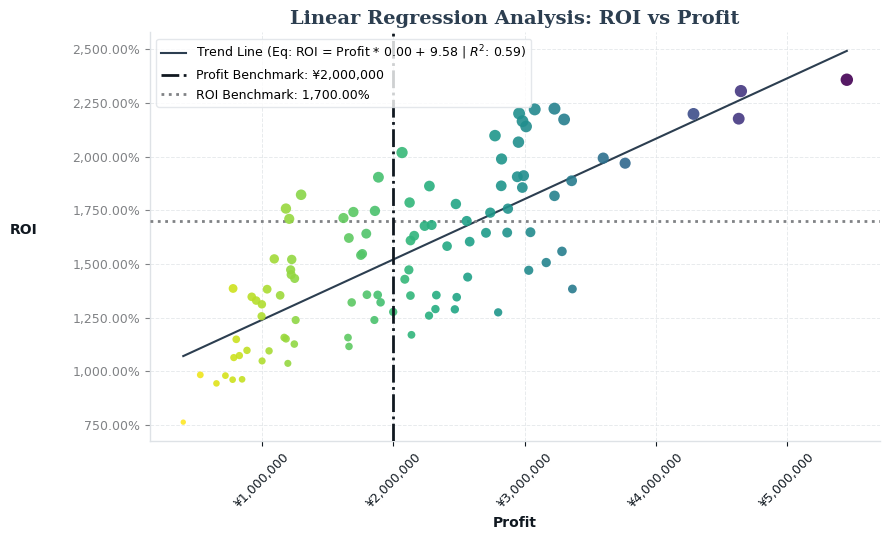

In [18]:
fig = generate_linear_regression_from_lists(simulated_x_distribution, simulated_y_distribution,
                                            variable_names.PROFIT, variable_names.ROI,
                                           x_benchmark=2000000, y_benchmark=17)
plt.show()

In [19]:
variables_2 = {variable_names.FINANCE_USD_TO_RMB: usd_to_rmb,
               variable_names.DEAL_SELLING_PRICE: selling_price,
               variable_names.DEAL_PURCHASING_PRICE: purchasing_price,
               variable_names.DEAL_ITEMS_PER_ORDER: items_per_order,
               variable_names.COST_ADVERTISING: advertising_budget,
               variable_names.COST_CPA: cpa,
               variable_names.COST_CONVERSION_RATE: conversion_rate,
               variable_names.EXPENSE: expense}

simulated_x_distribution, simulated_y_distribution, linear_trend_summary = stochastic_bivariate_simulation(
    variables=variables_2,
    independent_target_x=variable_names.COST_ADVERTISING,
    dependent_target_y=variable_names.NET_INCOME,
    shuffled_variables=[
        variable_names.COST_ADVERTISING,
        variable_names.DEAL_SELLING_PRICE,
        variable_names.DEAL_ITEMS_PER_ORDER],
    model_pipeline=[advertising_efficiency_model, cogs_model, revenue_model, cost_model,
                    depreciation_model, capital_expenditure_model,
                    net_income_model, profit_model, roi_model],
    sample_size=100)

print(linear_trend_summary)

{'slope': 91.97559936373509, 'intercept': -408463.33807672, 'r_squared': 0.40606001460918417, 'p_value': 1.0189897410604254e-12, 'standard_error': 11.236621646780325}


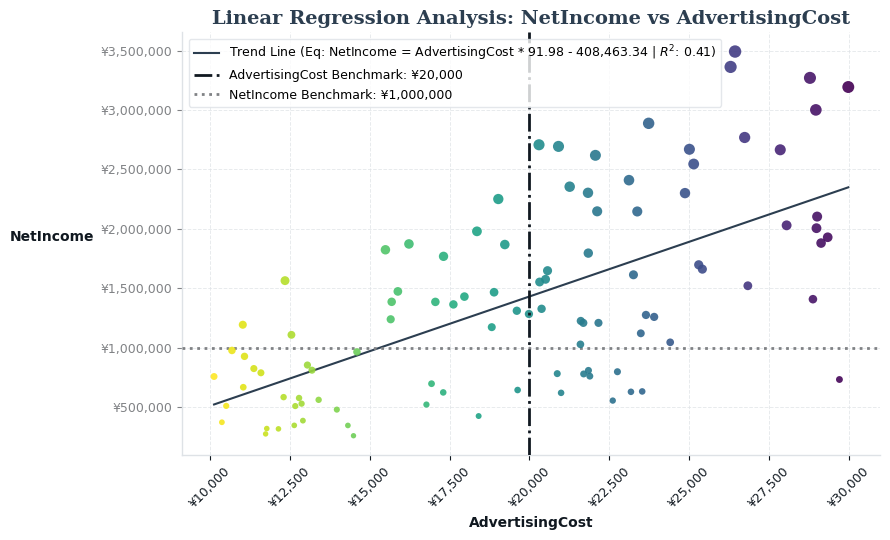

In [20]:
fig = generate_linear_regression_from_lists(simulated_x_distribution, simulated_y_distribution,
                                            variable_names.COST_ADVERTISING, variable_names.NET_INCOME,
                                            x_benchmark=20000, y_benchmark=1000000)
plt.show()

## Scenario 2

In [21]:
from src.models import CostOfGoodsSoldModel, TotalCostModel, RevenueModel, TotalExpenseModel, DepreciationModel, \
    CapitalExpenditureModel, NetIncomeModel, ProfitModel, AdvertisingEfficiencyGoogleSearchModel, \
    CostPerLeadGoogleSearchModel, ReturnOnAdvertisingSpendModel
from src.variables import GoogleSearchCostPerClick, AdvertisingBudget, GoogleSearchAllocationPercentage, \
    GoogleSearchConversionRate, CloseRate, ItemsPerOrder, SellingPrice, PurchasingPrice, USDToRMB

In [22]:
budget = AdvertisingBudget(3000, 2000, 5000)
google_search_allocation = GoogleSearchAllocationPercentage(0.6, 0.5, 0.7)
cpc = GoogleSearchCostPerClick(2.5, 1.8, 3.5)
cvr = GoogleSearchConversionRate(0.04, 0.02, 0.06)
close_rate = CloseRate(0.12, 0.08, 0.18)

items_per_order = ItemsPerOrder(2, 1.5, 3)
# selling_price = SellingPrice(8000, 5000, 10000)
selling_price = SellingPrice(3000, 2000, 4000)
purchasing_price = PurchasingPrice(2000, 1100, 2500)

usd_to_rmb = USDToRMB(6.8, 6.0, 7.5)

variables = {
    variable_names.COST_ADVERTISING: budget,
    variable_names.ALLOCATION_GOOGLE_SEARCH: google_search_allocation,
    variable_names.CPC_GOOGLE_SEARCH: cpc,
    variable_names.CONVERSION_RATE_GOOGLE_SEARCH: cvr,
    variable_names.CLOSE_RATE: close_rate,
    variable_names.DEAL_SELLING_PRICE: selling_price,
    variable_names.DEAL_PURCHASING_PRICE: purchasing_price,
    variable_names.DEAL_ITEMS_PER_ORDER: items_per_order,
    variable_names.FINANCE_USD_TO_RMB: usd_to_rmb,
}

cogs_model = CostOfGoodsSoldModel()
cost_model = TotalCostModel()
revenue_model = RevenueModel()
expense_model = TotalExpenseModel()
depreciation_model = DepreciationModel()
capital_expenditure_model = CapitalExpenditureModel()
net_income_model = NetIncomeModel()
profit_model = ProfitModel()

advertising_efficiency_google_search_model = AdvertisingEfficiencyGoogleSearchModel()
cost_per_lead_model = CostPerLeadGoogleSearchModel()
roas_model = ReturnOnAdvertisingSpendModel()

model_pipeline = [advertising_efficiency_google_search_model,
                  cogs_model, cost_model, revenue_model, net_income_model, profit_model, cost_per_lead_model, roas_model]

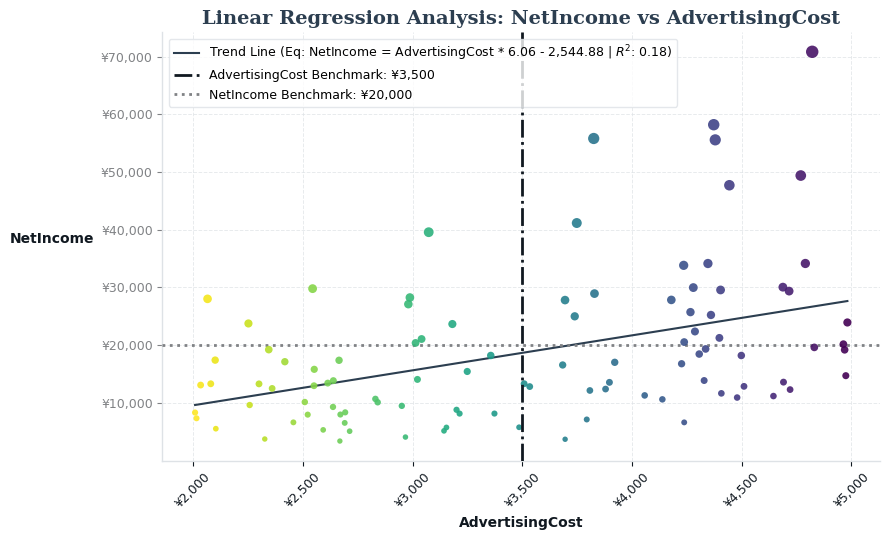

In [23]:
simulated_x_distribution, simulated_y_distribution, linear_trend_summary = stochastic_bivariate_simulation(
    variables=variables,
    independent_target_x=variable_names.COST_ADVERTISING,
    dependent_target_y=variable_names.NET_INCOME,
    shuffled_variables=[variable_names.COST_ADVERTISING,
                        variable_names.CPC_GOOGLE_SEARCH,
                        variable_names.CONVERSION_RATE_GOOGLE_SEARCH,
                        variable_names.CLOSE_RATE, 
                        variable_names.DEAL_SELLING_PRICE],
    model_pipeline=model_pipeline,
    sample_size=100)

fig = generate_linear_regression_from_lists(simulated_x_distribution, simulated_y_distribution,
                                            variable_names.COST_ADVERTISING, variable_names.NET_INCOME,
                                            x_benchmark=3500, y_benchmark=20000)
                                           
plt.show()

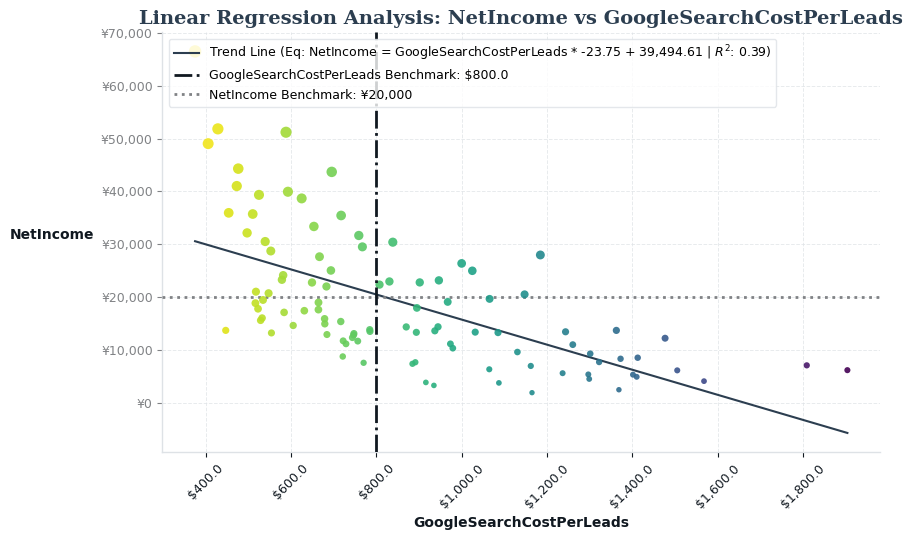

In [24]:
simulated_x_distribution, simulated_y_distribution, linear_trend_summary = stochastic_bivariate_simulation(
    variables=variables,
    independent_target_x=variable_names.CPL_GOOGLE_SEARCH,
    dependent_target_y=variable_names.NET_INCOME,
    shuffled_variables=[variable_names.COST_ADVERTISING,
                        variable_names.CPC_GOOGLE_SEARCH,
                        variable_names.CONVERSION_RATE_GOOGLE_SEARCH,
                        variable_names.CLOSE_RATE, 
                        variable_names.DEAL_SELLING_PRICE],
    model_pipeline=model_pipeline,
    sample_size=100)

fig = generate_linear_regression_from_lists(simulated_x_distribution, simulated_y_distribution,
                                            variable_names.CPL_GOOGLE_SEARCH, variable_names.NET_INCOME,
                                            x_benchmark=800, y_benchmark=20000)
                                           
plt.show()

the impact of cpl is more significant than that of ads budget on net income. Compared with ads budget where `$1` more increment on ads can bring `$7.61` net income, optimizing ads strategy by `$1` less on cpl can bring `$21.67` on net income